In [ ]:
import os
import re
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
# ─── CELL 1: IMPORTS ───
import os
import re
import math
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import mean_absolute_error, r2_score

# ─── CELL 2: LOAD FILES ───
dataset_path = "/content/drive/MyDrive/ECM_processed_cycles"
cycle_files = sorted([
    os.path.join(dataset_path, f)
    for f in os.listdir(dataset_path)
    if f.startswith("cycle_")
])
print("Total cycles:", len(cycle_files))

# ─── CELL 3: INITIAL CAPACITY ───
dt = 1.0
Q_used_all_cycles = []
for file in cycle_files:
    df = pd.read_csv(file)
    I = df['Current_measured'].fillna(0).values
    I_discharge = np.where(I < 0, -I, 0)
    Q_cycle = np.sum(I_discharge * dt) / 3600
    Q_used_all_cycles.append(Q_cycle)
initial_capacity = max(Q_used_all_cycles)
print("Initial capacity:", initial_capacity)

# ─── CELL 4: FILTER DISCHARGE CYCLES ───
discharge_cycle_files = []
for file in cycle_files:
    df = pd.read_csv(file)
    if df['SOC_ECM'].isna().all():
        continue
    I = df['Current_measured'].fillna(0).values
    I_discharge = np.where(I < 0, -I, 0)
    Q = np.sum(I_discharge * dt) / 3600
    if Q < 0.01:
        continue
    discharge_cycle_files.append(file)
print(f"Clean discharge cycles: {len(discharge_cycle_files)} / {len(cycle_files)}")

# ─── CELL 5: SPLIT ───
split       = int(0.8 * len(discharge_cycle_files))
train_files = discharge_cycle_files[:split]
val_files   = discharge_cycle_files[split:]
print(f"Train: {len(train_files)}  Val: {len(val_files)}")

# ─── CELL 6: GLOBAL STATS ───
def compute_global_stats(files):
    num_cols = [
        'Voltage_measured', 'Current_measured', 'dV_dt', 'dT_dt',
        'V_RC_masked', 'V_ECM_masked', 'power', 'Temperature_measured'
    ]
    all_data = []
    for file in files:
        df = pd.read_csv(file)
        df = df.ffill().fillna(0)
        if 'mode_flag' not in df.columns:
            df['mode_flag'] = (df['Current_measured'] < 0).astype(int)
        df['V_RC_masked']  = df['V_RC']  * df['mode_flag']
        df['V_ECM_masked'] = df['V_ECM'] * df['mode_flag']
        df['power']        = df['Voltage_measured'] * df['Current_measured']
        all_data.append(df[num_cols])
    all_data = pd.concat(all_data)
    return all_data.mean(), all_data.std() + 1e-8

global_mean, global_std = compute_global_stats(train_files)

# ─── CELL 7: DATASET ───
class BatteryDataset(Dataset):
    def __init__(self, files, seq_len=64, dt=1.0,
                 initial_capacity=None,
                 global_mean=None, global_std=None):

        self.seq_len = seq_len
        self.samples = []
        self.dt = dt
        self.initial_capacity = initial_capacity

        num_cols = [
            'Voltage_measured', 'Current_measured',
            'dV_dt', 'dT_dt', 'V_RC_masked', 'V_ECM_masked',
            'power', 'Temperature_measured'
        ]

        all_cycles = [int(re.findall(r'\d+', f)[-1]) for f in files]
        max_cycles = max(all_cycles)

        for file in files:
            df = pd.read_csv(file)
            df = df.ffill().fillna(0)

            df['SOC_ECM'] = df['SOC_ECM'].interpolate().ffill().bfill()

            cycle_num  = int(re.findall(r'\d+', file)[-1])
            cycle_norm = cycle_num / max_cycles
            df['cycle_index'] = cycle_norm

            if 'mode_flag' not in df.columns:
                df['mode_flag'] = (df['Current_measured'] < 0).astype(int)

            df['Time_uniform'] = df['Time_uniform'] / (df['Time_uniform'].max() + 1e-8)

            df['V_RC_masked']  = df['V_RC']  * df['mode_flag']
            df['V_ECM_masked'] = df['V_ECM'] * df['mode_flag']
            df['power']        = df['Voltage_measured'] * df['Current_measured']

            I = df['Current_measured'].values
            I_discharge = np.where(I < 0, -I, 0)
            Q_cycle   = np.sum(I_discharge * self.dt) / 3600
            soh_value = np.clip(Q_cycle / self.initial_capacity, 0.0, 1.0)
            soh_target = np.full(len(df), soh_value)

            # global normalization — Temperature_measured included
            df[num_cols] = (df[num_cols] - global_mean) / global_std

            feature_cols = [
                'Voltage_measured', 'Current_measured', 'Time_uniform',
                'dV_dt', 'dT_dt', 'mode_flag', 'V_RC_masked',
                'V_ECM_masked', 'power', 'cycle_index', 'Temperature_measured'
            ]

            features    = df[feature_cols].values
            soc_target  = df['SOC_ECM'].values
            # temp target is normalized Temperature_measured — already normalized above
            temp_target = df['Temperature_measured'].values

            for i in range(len(df) - seq_len):
                x      = features[i:i+seq_len]
                y_soc  = soc_target[i+seq_len]
                y_soh  = soh_target[i+seq_len]
                y_temp = temp_target[i+seq_len]
                self.samples.append((x, y_soc, y_soh, y_temp))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        x, y_soc, y_soh, y_temp = self.samples[idx]
        return (
            torch.tensor(x, dtype=torch.float32),
            torch.tensor(y_soc, dtype=torch.float32),
            torch.tensor(y_soh, dtype=torch.float32),
            torch.tensor(y_temp, dtype=torch.float32),
        )

train_dataset = BatteryDataset(
    train_files, dt=1.0,
    initial_capacity=initial_capacity,
    global_mean=global_mean,
    global_std=global_std
)
val_dataset = BatteryDataset(
    val_files, dt=1.0,
    initial_capacity=initial_capacity,
    global_mean=global_mean,
    global_std=global_std
)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=64, shuffle=False)

# ─── CELL 8: POSITIONAL ENCODING ───
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer("pe", pe)

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

# ─── CELL 9: MODEL ───
class BatteryTransformer(nn.Module):
    def __init__(self, input_dim=11, d_model=128, nhead=4, num_layers=2, dropout=0.2):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, d_model)
        self.pos_encoder = PositionalEncoding(d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=256, dropout=dropout,
            batch_first=True
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        decoder_layer = nn.TransformerDecoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=256, dropout=dropout,
            batch_first=True
        )
        self.decoder = nn.TransformerDecoder(decoder_layer, num_layers=num_layers)

        # 3 query tokens — one per target
        self.query_embed = nn.Parameter(torch.randn(1, 3, d_model))

        self.soc_mu_head      = nn.Linear(d_model, 1)
        self.soc_logvar_head  = nn.Linear(d_model, 1)
        self.soh_mu_head      = nn.Linear(d_model, 1)
        self.soh_logvar_head  = nn.Linear(d_model, 1)
        self.temp_mu_head     = nn.Linear(d_model, 1)
        self.temp_logvar_head = nn.Linear(d_model, 1)

        for head in [self.soc_logvar_head, self.soh_logvar_head, self.temp_logvar_head]:
            nn.init.zeros_(head.weight)
            nn.init.zeros_(head.bias)

    def forward(self, x):
        batch_size = x.size(0)
        x = self.input_proj(x)
        x = self.pos_encoder(x)
        memory = self.encoder(x)

        queries = self.query_embed.expand(batch_size, -1, -1)
        decoded = self.decoder(queries, memory)

        soc_feat  = decoded[:, 0, :]
        soh_feat  = decoded[:, 1, :]
        temp_feat = decoded[:, 2, :]

        soc_mu      = self.soc_mu_head(soc_feat)
        soc_logvar  = self.soc_logvar_head(soc_feat.detach())
        soh_mu      = self.soh_mu_head(soh_feat)
        soh_logvar  = self.soh_logvar_head(soh_feat.detach())
        temp_mu     = self.temp_mu_head(temp_feat)
        temp_logvar = self.temp_logvar_head(temp_feat.detach())

        soc  = torch.cat([soc_mu,  soc_logvar],  dim=1)
        soh  = torch.cat([soh_mu,  soh_logvar],  dim=1)
        temp = torch.cat([temp_mu, temp_logvar], dim=1)
        return soc, soh, temp

# ─── CELL 10: TRAINING SETUP ───
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

model = BatteryTransformer(input_dim=11).to(device)

def gaussian_nll(pred, target):
    mean    = pred[:, 0]
    log_var = pred[:, 1]
    log_var = torch.clamp(log_var, -2, 2)
    precision = torch.exp(-log_var)
    loss = 0.5 * (precision * (target - mean)**2 + log_var)
    loss += 0.01 * (log_var ** 2)
    return torch.mean(loss)

optimizer = torch.optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=3, factor=0.5
)

# ─── CELL 11: TRAINING LOOP ───
EPOCHS = 50
best_val_loss = float('inf')
patience_counter = 0
PATIENCE = 5

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0
    for x, soc_y, soh_y, temp_y in train_loader:
        x      = x.to(device)
        soc_y  = soc_y.to(device)
        soh_y  = soh_y.to(device)
        temp_y = temp_y.to(device)
        optimizer.zero_grad()
        soc_pred, soh_pred, temp_pred = model(x)
        loss = (gaussian_nll(soc_pred, soc_y) +
                0.5 * gaussian_nll(soh_pred, soh_y) +
                1.5 * gaussian_nll(temp_pred, temp_y))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    model.eval()
    val_loss = 0
    all_soc_true,  all_soc_pred  = [], []
    all_soh_true,  all_soh_pred  = [], []
    all_temp_true, all_temp_pred = [], []
    all_soc_conf, all_soh_conf, all_temp_conf = [], [], []

    with torch.no_grad():
        for x, soc_y, soh_y, temp_y in val_loader:
            x      = x.to(device)
            soc_y  = soc_y.to(device)
            soh_y  = soh_y.to(device)
            temp_y = temp_y.to(device)
            soc_pred, soh_pred, temp_pred = model(x)
            soc_pred  = torch.nan_to_num(soc_pred)
            soh_pred  = torch.nan_to_num(soh_pred)
            temp_pred = torch.nan_to_num(temp_pred)
            loss = (gaussian_nll(soc_pred, soc_y) +
                    0.5 * gaussian_nll(soh_pred, soh_y) +
                    1.5 * gaussian_nll(temp_pred, temp_y))
            val_loss += loss.item()
            all_soc_true.extend(soc_y.cpu().numpy())
            all_soc_pred.extend(soc_pred[:, 0].cpu().numpy())
            all_soh_true.extend(soh_y.cpu().numpy())
            all_soh_pred.extend(soh_pred[:, 0].cpu().numpy())
            all_temp_true.extend(temp_y.cpu().numpy())
            all_temp_pred.extend(temp_pred[:, 0].cpu().numpy())
            all_soc_conf.extend((1 / (1 + torch.exp(soc_pred[:, 1]))).cpu().numpy())
            all_soh_conf.extend((1 / (1 + torch.exp(soh_pred[:, 1]))).cpu().numpy())
            all_temp_conf.extend((1 / (1 + torch.exp(temp_pred[:, 1]))).cpu().numpy())

    val_loss /= len(val_loader)

    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss {train_loss:.4f}  Val Loss {val_loss:.4f}")
    print(f"SOC  R2 {r2_score(all_soc_true,  all_soc_pred):.4f}  MAE {mean_absolute_error(all_soc_true,  all_soc_pred):.4f}")
    print(f"SOH  R2 {r2_score(all_soh_true,  all_soh_pred):.4f}  MAE {mean_absolute_error(all_soh_true,  all_soh_pred):.4f}")
    print(f"TEMP R2 {r2_score(all_temp_true, all_temp_pred):.4f}  MAE {mean_absolute_error(all_temp_true, all_temp_pred):.4f}")
    print(f"SOC  Confidence {np.mean(all_soc_conf):.4f}")
    print(f"SOH  Confidence {np.mean(all_soh_conf):.4f}")
    print(f"TEMP Confidence {np.mean(all_temp_conf):.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), 'best_model.pt')
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print("Early stopping triggered")
            break

    scheduler.step(val_loss)

Total cycles: 341
Initial capacity: 1.7059162227905784
Clean discharge cycles: 171 / 341
Train: 136  Val: 35
cuda

Epoch 1/50
Train Loss -2.8281  Val Loss -2.8563
SOC  R2 0.9870  MAE 0.0165
SOH  R2 0.5967  MAE 0.0764
TEMP R2 0.9993  MAE 0.0149
SOC  Confidence 0.9515
SOH  Confidence 0.9477
TEMP Confidence 0.9667

Epoch 2/50
Train Loss -2.8755  Val Loss -2.8632
SOC  R2 0.9941  MAE 0.0102
SOH  R2 0.6988  MAE 0.0556
TEMP R2 0.9997  MAE 0.0092
SOC  Confidence 0.9535
SOH  Confidence 0.9562
TEMP Confidence 0.9700

Epoch 3/50
Train Loss -2.8772  Val Loss -2.8629
SOC  R2 0.9945  MAE 0.0100
SOH  R2 0.6767  MAE 0.0551
TEMP R2 0.9999  MAE 0.0060
SOC  Confidence 0.9440
SOH  Confidence 0.9515
TEMP Confidence 0.9771

Epoch 4/50
Train Loss -2.8778  Val Loss -2.8657
SOC  R2 0.9969  MAE 0.0072
SOH  R2 0.7276  MAE 0.0519
TEMP R2 0.9999  MAE 0.0060
SOC  Confidence 0.9317
SOH  Confidence 0.9407
TEMP Confidence 0.9763

Epoch 5/50
Train Loss -2.8782  Val Loss -2.8611
SOC  R2 0.9957  MAE 0.0092
SOH  R2 0.6357

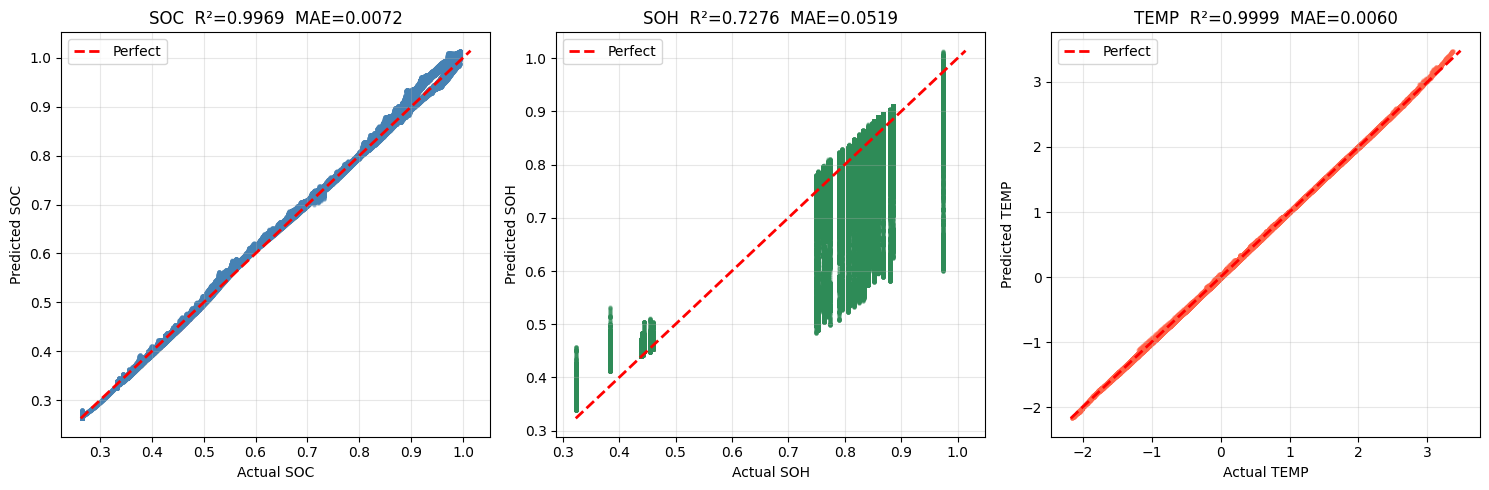

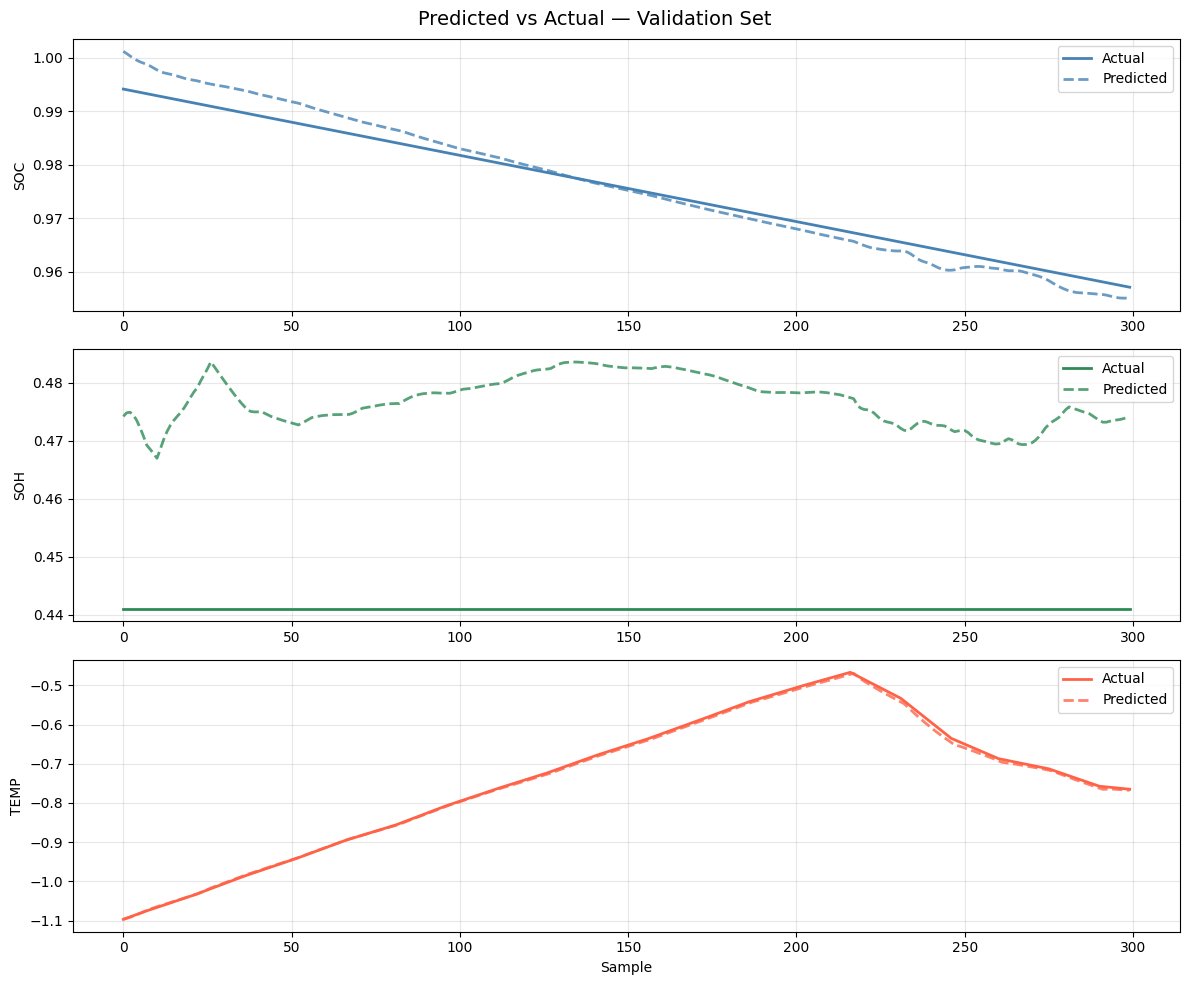

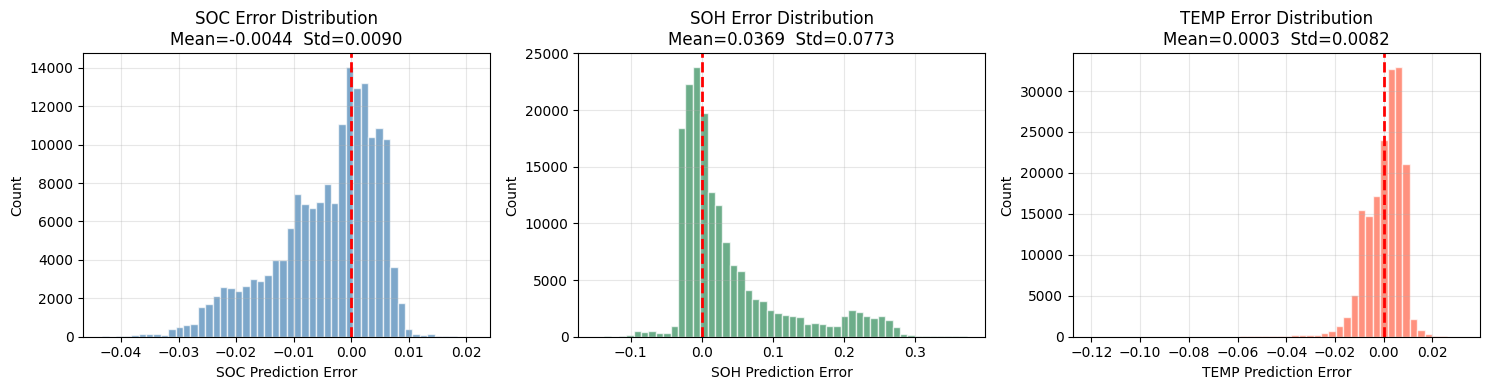


─── Final Metrics on Validation Set ───
SOC  R²=0.9969  MAE=0.0072
SOH  R²=0.7276  MAE=0.0519
TEMP R²=0.9999  MAE=0.0060


In [10]:
# ─── load best model ───
model.load_state_dict(torch.load('best_model.pt'))
model.eval()

# ─── collect val predictions ───
import matplotlib.pyplot as plt

all_soc_true,  all_soc_pred  = [], []
all_soh_true,  all_soh_pred  = [], []
all_temp_true, all_temp_pred = [], []

with torch.no_grad():
    for x, soc_y, soh_y, temp_y in val_loader:
        x      = x.to(device)
        soc_y  = soc_y.to(device)
        soh_y  = soh_y.to(device)
        temp_y = temp_y.to(device)
        soc_pred, soh_pred, temp_pred = model(x)
        all_soc_true.extend(soc_y.cpu().numpy())
        all_soc_pred.extend(soc_pred[:, 0].cpu().numpy())
        all_soh_true.extend(soh_y.cpu().numpy())
        all_soh_pred.extend(soh_pred[:, 0].cpu().numpy())
        all_temp_true.extend(temp_y.cpu().numpy())
        all_temp_pred.extend(temp_pred[:, 0].cpu().numpy())

all_soc_true  = np.array(all_soc_true)
all_soc_pred  = np.array(all_soc_pred)
all_soh_true  = np.array(all_soh_true)
all_soh_pred  = np.array(all_soh_pred)
all_temp_true = np.array(all_temp_true)
all_temp_pred = np.array(all_temp_pred)

# ─── PLOT 1: Predicted vs Actual scatter ───
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, true, pred, title, color in zip(
    axes,
    [all_soc_true, all_soh_true, all_temp_true],
    [all_soc_pred, all_soh_pred, all_temp_pred],
    ['SOC', 'SOH', 'TEMP'],
    ['steelblue', 'seagreen', 'tomato']
):
    r2  = r2_score(true, pred)
    mae = mean_absolute_error(true, pred)
    ax.scatter(true, pred, alpha=0.3, s=5, color=color)
    mn, mx = min(true.min(), pred.min()), max(true.max(), pred.max())
    ax.plot([mn, mx], [mn, mx], 'r--', linewidth=2, label='Perfect')
    ax.set_xlabel(f'Actual {title}')
    ax.set_ylabel(f'Predicted {title}')
    ax.set_title(f'{title}  R²={r2:.4f}  MAE={mae:.4f}')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('predicted_vs_actual.png', dpi=300, bbox_inches='tight')
plt.show()

# ─── PLOT 2: Time series prediction ───
fig, axes = plt.subplots(3, 1, figsize=(12, 10))
n = 300  # show first 300 samples

for ax, true, pred, title, color in zip(
    axes,
    [all_soc_true[:n], all_soh_true[:n], all_temp_true[:n]],
    [all_soc_pred[:n], all_soh_pred[:n], all_temp_pred[:n]],
    ['SOC', 'SOH', 'TEMP'],
    ['steelblue', 'seagreen', 'tomato']
):
    ax.plot(true, label='Actual',    color=color, linewidth=2)
    ax.plot(pred, label='Predicted', color=color, linewidth=2,
            linestyle='--', alpha=0.8)
    ax.set_ylabel(title)
    ax.legend()
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Sample')
plt.suptitle('Predicted vs Actual — Validation Set', fontsize=14)
plt.tight_layout()
plt.savefig('timeseries_prediction.png', dpi=300, bbox_inches='tight')
plt.show()

# ─── PLOT 3: Error distribution ───
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, true, pred, title, color in zip(
    axes,
    [all_soc_true, all_soh_true, all_temp_true],
    [all_soc_pred, all_soh_pred, all_temp_pred],
    ['SOC', 'SOH', 'TEMP'],
    ['steelblue', 'seagreen', 'tomato']
):
    errors = true - pred
    ax.hist(errors, bins=50, color=color, alpha=0.7, edgecolor='white')
    ax.axvline(0, color='red', linestyle='--', linewidth=2)
    ax.set_xlabel(f'{title} Prediction Error')
    ax.set_ylabel('Count')
    ax.set_title(f'{title} Error Distribution\nMean={errors.mean():.4f}  Std={errors.std():.4f}')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('error_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# ─── print final metrics ───
print("\n─── Final Metrics on Validation Set ───")
print(f"SOC  R²={r2_score(all_soc_true,  all_soc_pred):.4f}  MAE={mean_absolute_error(all_soc_true,  all_soc_pred):.4f}")
print(f"SOH  R²={r2_score(all_soh_true,  all_soh_pred):.4f}  MAE={mean_absolute_error(all_soh_true,  all_soh_pred):.4f}")
print(f"TEMP R²={r2_score(all_temp_true, all_temp_pred):.4f}  MAE={mean_absolute_error(all_temp_true, all_temp_pred):.4f}")

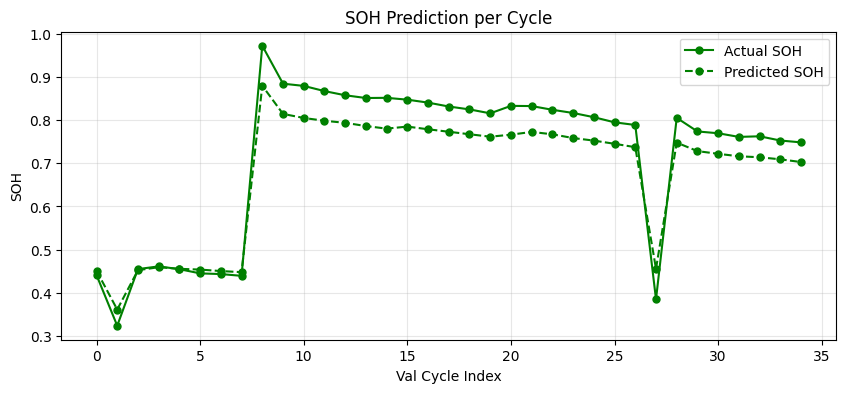

In [11]:
# proper SOH visualization — one point per cycle
cycle_soh_true = []
cycle_soh_pred = []

for file in val_files:
    df = pd.read_csv(file)
    I = df['Current_measured'].fillna(0).values
    I_discharge = np.where(I < 0, -I, 0)
    Q = np.sum(I_discharge * dt) / 3600
    true_soh = np.clip(Q / initial_capacity, 0.0, 1.0)
    cycle_soh_true.append(true_soh)

# get predicted SOH per cycle — average predictions for that cycle
model.eval()
with torch.no_grad():
    for file in val_files:
        # load sequences from this cycle only
        temp_dataset = BatteryDataset(
            [file], dt=1.0,
            initial_capacity=initial_capacity,
            global_mean=global_mean,
            global_std=global_std
        )
        temp_loader = DataLoader(temp_dataset, batch_size=64, shuffle=False)
        preds = []
        for x, soc_y, soh_y, temp_y in temp_loader:
            x = x.to(device)
            _, soh_pred, _ = model(x)
            preds.extend(soh_pred[:, 0].cpu().numpy())
        cycle_soh_pred.append(np.mean(preds))

# plot
plt.figure(figsize=(10, 4))
plt.plot(cycle_soh_true, 'g-o', label='Actual SOH',    markersize=5)
plt.plot(cycle_soh_pred, 'g--o', label='Predicted SOH', markersize=5)
plt.xlabel('Val Cycle Index')
plt.ylabel('SOH')
plt.title('SOH Prediction per Cycle')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('soh_per_cycle.png', dpi=300, bbox_inches='tight')
plt.show()

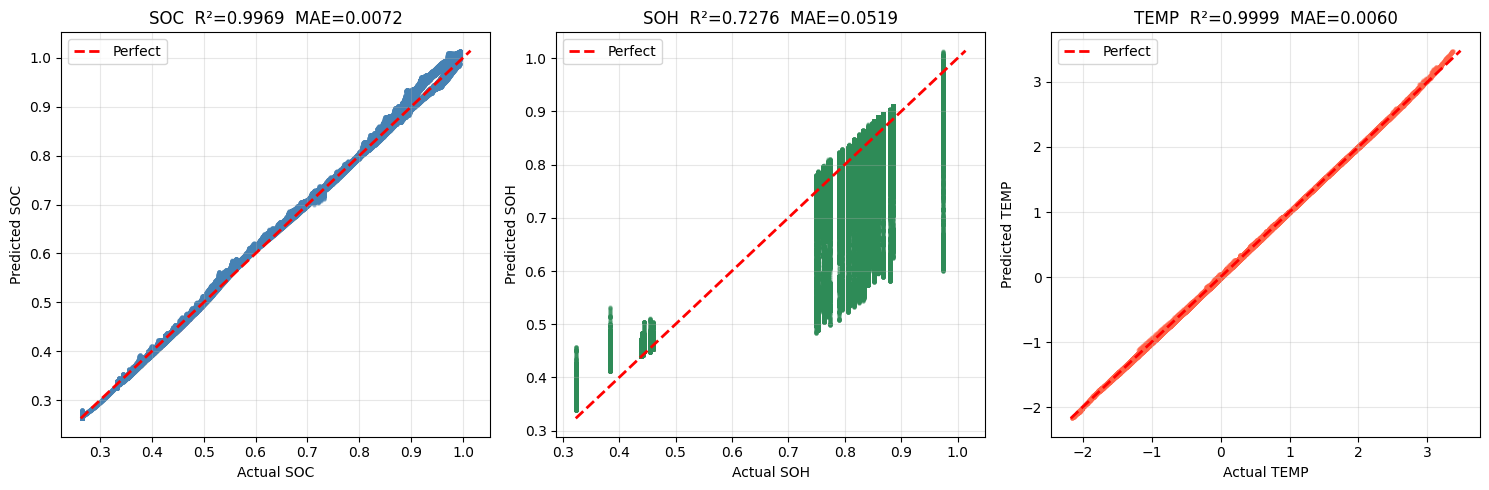

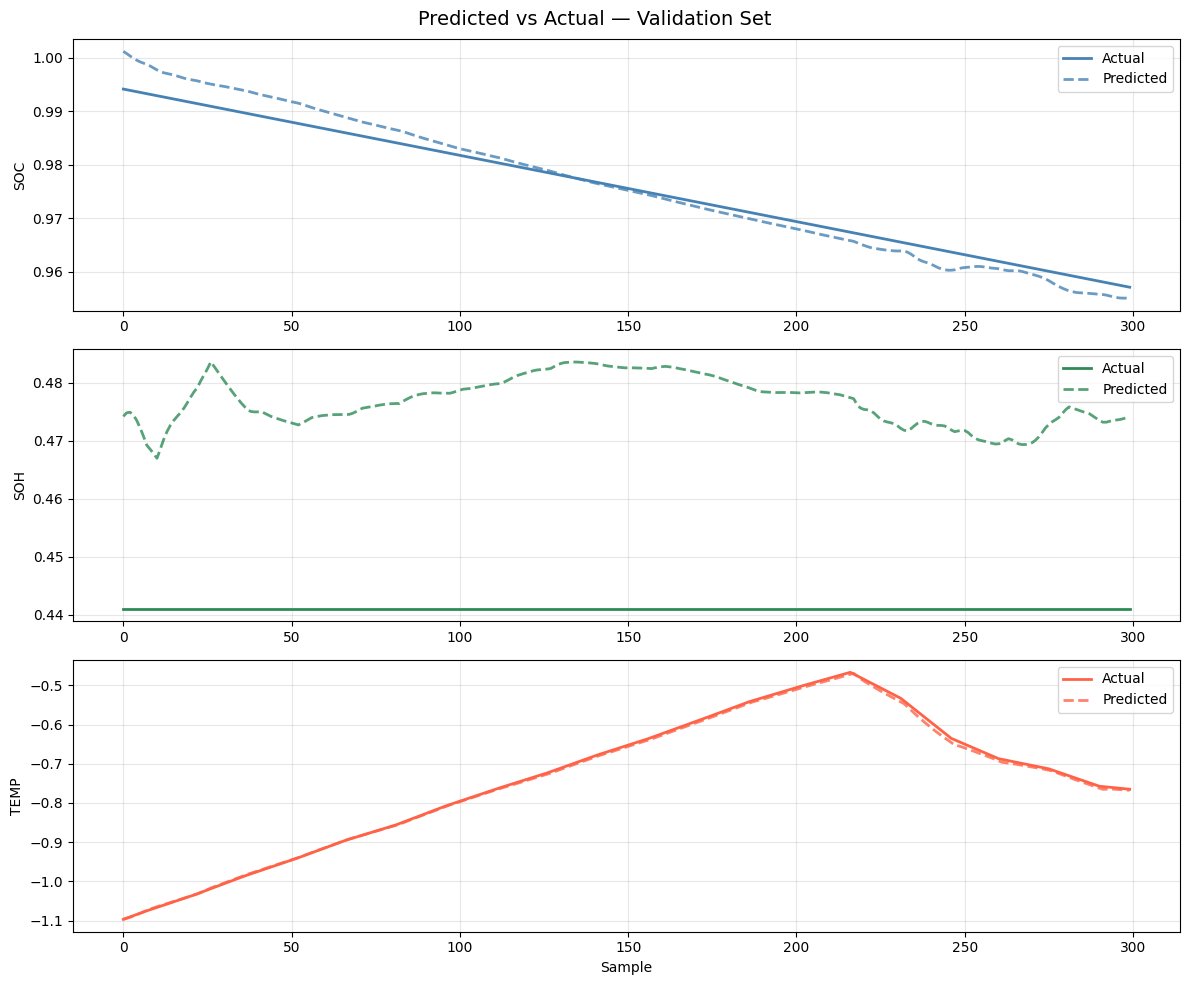

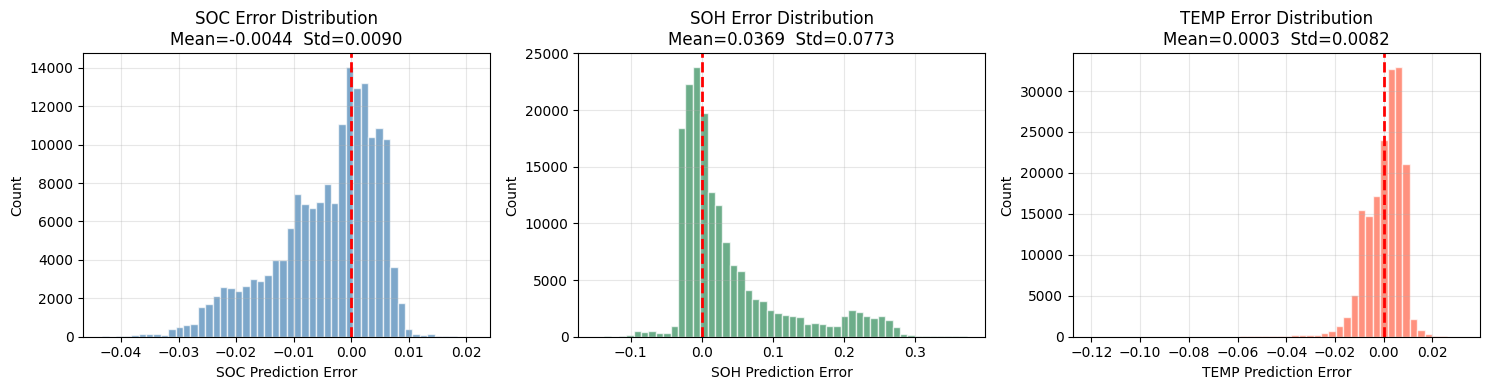

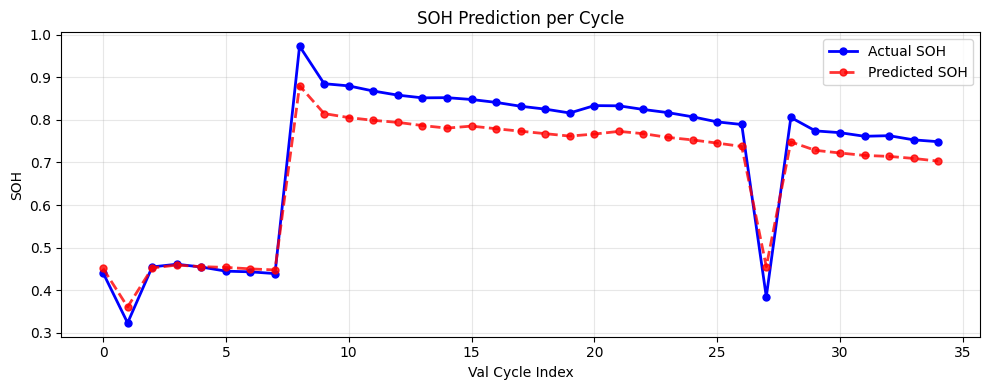


─── Final Metrics on Validation Set ───
SOC  R²=0.9969  MAE=0.0072
SOH  R²=0.7276  MAE=0.0519
TEMP R²=0.9999  MAE=0.0060

SOH per-cycle R²=0.9110  MAE=0.0480


In [12]:
# ─── load best model ───
model.load_state_dict(torch.load('best_model.pt'))
model.eval()

# ─── collect val predictions ───
import matplotlib.pyplot as plt

all_soc_true,  all_soc_pred  = [], []
all_soh_true,  all_soh_pred  = [], []
all_temp_true, all_temp_pred = [], []

with torch.no_grad():
    for x, soc_y, soh_y, temp_y in val_loader:
        x      = x.to(device)
        soc_y  = soc_y.to(device)
        soh_y  = soh_y.to(device)
        temp_y = temp_y.to(device)
        soc_pred, soh_pred, temp_pred = model(x)
        all_soc_true.extend(soc_y.cpu().numpy())
        all_soc_pred.extend(soc_pred[:, 0].cpu().numpy())
        all_soh_true.extend(soh_y.cpu().numpy())
        all_soh_pred.extend(soh_pred[:, 0].cpu().numpy())
        all_temp_true.extend(temp_y.cpu().numpy())
        all_temp_pred.extend(temp_pred[:, 0].cpu().numpy())

all_soc_true  = np.array(all_soc_true)
all_soc_pred  = np.array(all_soc_pred)
all_soh_true  = np.array(all_soh_true)
all_soh_pred  = np.array(all_soh_pred)
all_temp_true = np.array(all_temp_true)
all_temp_pred = np.array(all_temp_pred)

# ─── PLOT 1: Predicted vs Actual scatter ───
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, true, pred, title, color in zip(
    axes,
    [all_soc_true, all_soh_true, all_temp_true],
    [all_soc_pred, all_soh_pred, all_temp_pred],
    ['SOC', 'SOH', 'TEMP'],
    ['steelblue', 'seagreen', 'tomato']
):
    r2  = r2_score(true, pred)
    mae = mean_absolute_error(true, pred)
    ax.scatter(true, pred, alpha=0.3, s=5, color=color)
    mn, mx = min(true.min(), pred.min()), max(true.max(), pred.max())
    ax.plot([mn, mx], [mn, mx], 'r--', linewidth=2, label='Perfect')
    ax.set_xlabel(f'Actual {title}')
    ax.set_ylabel(f'Predicted {title}')
    ax.set_title(f'{title}  R²={r2:.4f}  MAE={mae:.4f}')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('predicted_vs_actual.png', dpi=300, bbox_inches='tight')
plt.show()

# ─── PLOT 2: Time series prediction ───
fig, axes = plt.subplots(3, 1, figsize=(12, 10))
n = 300

for ax, true, pred, title, color in zip(
    axes,
    [all_soc_true[:n], all_soh_true[:n], all_temp_true[:n]],
    [all_soc_pred[:n], all_soh_pred[:n], all_temp_pred[:n]],
    ['SOC', 'SOH', 'TEMP'],
    ['steelblue', 'seagreen', 'tomato']
):
    ax.plot(true, label='Actual',    color=color, linewidth=2)
    ax.plot(pred, label='Predicted', color=color, linewidth=2,
            linestyle='--', alpha=0.8)
    ax.set_ylabel(title)
    ax.legend()
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Sample')
plt.suptitle('Predicted vs Actual — Validation Set', fontsize=14)
plt.tight_layout()
plt.savefig('timeseries_prediction.png', dpi=300, bbox_inches='tight')
plt.show()

# ─── PLOT 3: Error distribution ───
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, true, pred, title, color in zip(
    axes,
    [all_soc_true, all_soh_true, all_temp_true],
    [all_soc_pred, all_soh_pred, all_temp_pred],
    ['SOC', 'SOH', 'TEMP'],
    ['steelblue', 'seagreen', 'tomato']
):
    errors = true - pred
    ax.hist(errors, bins=50, color=color, alpha=0.7, edgecolor='white')
    ax.axvline(0, color='red', linestyle='--', linewidth=2)
    ax.set_xlabel(f'{title} Prediction Error')
    ax.set_ylabel('Count')
    ax.set_title(f'{title} Error Distribution\nMean={errors.mean():.4f}  Std={errors.std():.4f}')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('error_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# ─── PLOT 4: SOH per cycle ───
cycle_soh_true = []
cycle_soh_pred = []

model.eval()
with torch.no_grad():
    for file in val_files:
        # true SOH from discharge current
        df = pd.read_csv(file)
        I = df['Current_measured'].fillna(0).values
        I_discharge = np.where(I < 0, -I, 0)
        Q = np.sum(I_discharge * dt) / 3600
        true_soh = np.clip(Q / initial_capacity, 0.0, 1.0)
        cycle_soh_true.append(true_soh)

        # predicted SOH — average across all sequences in this cycle
        temp_dataset = BatteryDataset(
            [file], dt=1.0,
            initial_capacity=initial_capacity,
            global_mean=global_mean,
            global_std=global_std
        )
        temp_loader = DataLoader(temp_dataset, batch_size=64, shuffle=False)
        preds = []
        for x, soc_y, soh_y, temp_y in temp_loader:
            x = x.to(device)
            _, soh_pred, _ = model(x)
            preds.extend(soh_pred[:, 0].cpu().numpy())
        cycle_soh_pred.append(np.mean(preds))

plt.figure(figsize=(10, 4))
plt.plot(cycle_soh_true, 'b-o',  label='Actual SOH',    markersize=5, linewidth=2)
plt.plot(cycle_soh_pred, 'r--o', label='Predicted SOH', markersize=5, linewidth=2, alpha=0.8)
plt.xlabel('Val Cycle Index')
plt.ylabel('SOH')
plt.title('SOH Prediction per Cycle')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('soh_per_cycle.png', dpi=300, bbox_inches='tight')
plt.show()

# ─── print final metrics ───
print("\n─── Final Metrics on Validation Set ───")
print(f"SOC  R²={r2_score(all_soc_true,  all_soc_pred):.4f}  MAE={mean_absolute_error(all_soc_true,  all_soc_pred):.4f}")
print(f"SOH  R²={r2_score(all_soh_true,  all_soh_pred):.4f}  MAE={mean_absolute_error(all_soh_true,  all_soh_pred):.4f}")
print(f"TEMP R²={r2_score(all_temp_true, all_temp_pred):.4f}  MAE={mean_absolute_error(all_temp_true, all_temp_pred):.4f}")
print(f"\nSOH per-cycle R²={r2_score(cycle_soh_true, cycle_soh_pred):.4f}  MAE={mean_absolute_error(cycle_soh_true, cycle_soh_pred):.4f}")

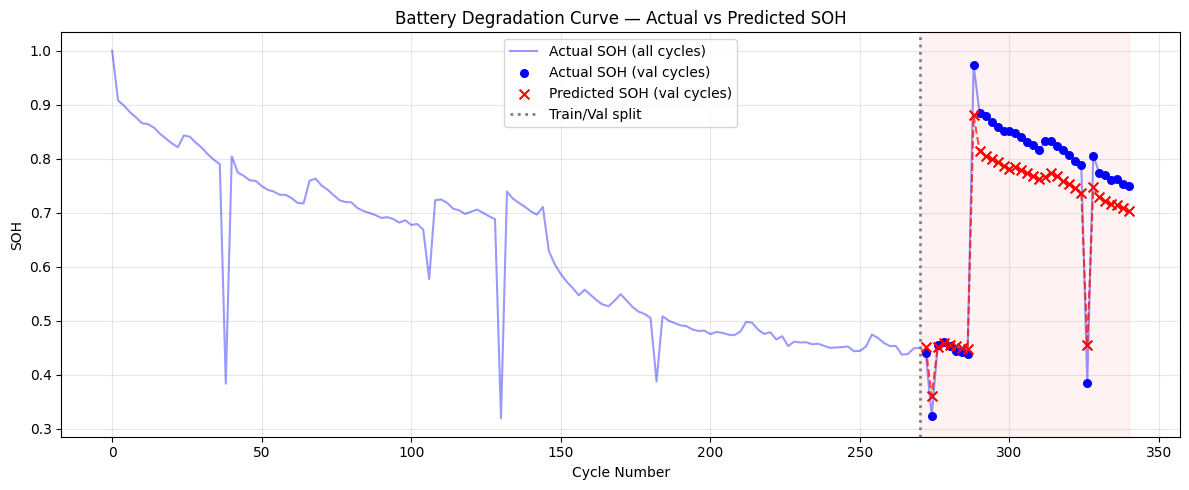


SOH per-cycle R²=0.9110  MAE=0.0480


In [13]:
 # ─── PLOT 4: SOH across all cycles (degradation curve) ───
all_cycle_soh_true = []
all_cycle_soh_pred = []
all_cycle_numbers  = []

model.eval()
with torch.no_grad():
    for file in discharge_cycle_files:  # all cycles not just val
        # true SOH
        df = pd.read_csv(file)
        I = df['Current_measured'].fillna(0).values
        I_discharge = np.where(I < 0, -I, 0)
        Q = np.sum(I_discharge * dt) / 3600
        true_soh = np.clip(Q / initial_capacity, 0.0, 1.0)
        all_cycle_soh_true.append(true_soh)

        # cycle number for x axis
        cycle_num = int(re.findall(r'\d+', file)[-1])
        all_cycle_numbers.append(cycle_num)

        # predicted SOH — only for val files, train files get None
        if file in val_files:
            temp_dataset = BatteryDataset(
                [file], dt=1.0,
                initial_capacity=initial_capacity,
                global_mean=global_mean,
                global_std=global_std
            )
            temp_loader = DataLoader(temp_dataset, batch_size=64, shuffle=False)
            preds = []
            for x, soc_y, soh_y, temp_y in temp_loader:
                x = x.to(device)
                _, soh_pred, _ = model(x)
                preds.extend(soh_pred[:, 0].cpu().numpy())
            all_cycle_soh_pred.append(np.mean(preds))
        else:
            all_cycle_soh_pred.append(None)

# split into val only for predicted line
val_indices = [i for i, f in enumerate(discharge_cycle_files) if f in val_files]
val_cycle_numbers  = [all_cycle_numbers[i]  for i in val_indices]
val_cycle_soh_true = [all_cycle_soh_true[i] for i in val_indices]
val_cycle_soh_pred = [all_cycle_soh_pred[i] for i in val_indices]

plt.figure(figsize=(12, 5))

# full degradation curve (all cycles)
plt.plot(all_cycle_numbers, all_cycle_soh_true,
         'b-', linewidth=1.5, alpha=0.4, label='Actual SOH (all cycles)')

# val cycles actual
plt.scatter(val_cycle_numbers, val_cycle_soh_true,
            color='blue', s=30, zorder=3, label='Actual SOH (val cycles)')

# val cycles predicted
plt.scatter(val_cycle_numbers, val_cycle_soh_pred,
            color='red', marker='x', s=50, zorder=4, label='Predicted SOH (val cycles)')

# connect predicted points
plt.plot(val_cycle_numbers, val_cycle_soh_pred,
         'r--', linewidth=1.5, alpha=0.7)

# shade train/val boundary
train_end = all_cycle_numbers[int(0.8 * len(discharge_cycle_files)) - 1]
plt.axvline(train_end, color='gray', linestyle=':', linewidth=2, label='Train/Val split')
plt.axvspan(train_end, max(all_cycle_numbers), alpha=0.05, color='red')

plt.xlabel('Cycle Number')
plt.ylabel('SOH')
plt.title('Battery Degradation Curve — Actual vs Predicted SOH')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('soh_degradation_curve.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nSOH per-cycle R²={r2_score(val_cycle_soh_true, val_cycle_soh_pred):.4f}  MAE={mean_absolute_error(val_cycle_soh_true, val_cycle_soh_pred):.4f}")

In [15]:
from sklearn.metrics import mean_squared_error

print(f"SOC  RMSE={np.sqrt(mean_squared_error(all_soc_true, all_soc_pred)):.4f}")
print(f"SOH  RMSE={np.sqrt(mean_squared_error(all_soh_true, all_soh_pred)):.4f}")
print(f"TEMP RMSE={np.sqrt(mean_squared_error(all_temp_true, all_temp_pred)):.4f}")

SOC  RMSE=0.0100
SOH  RMSE=0.0857
TEMP RMSE=0.0082


In [17]:
from sklearn.metrics import mean_squared_error

print("\n" + "="*55)
print(f"{'Metric':<12} {'R²':>8} {'MAE':>8} {'RMSE':>8}")
print("="*55)
for name, true, pred in [
    ('SOC',  all_soc_true,  all_soc_pred),
    ('SOH',  all_soh_true,  all_soh_pred),
    ('TEMP', all_temp_true, all_temp_pred),
]:
    r2   = r2_score(true, pred)
    mae  = mean_absolute_error(true, pred)
    rmse = np.sqrt(mean_squared_error(true, pred))
    print(f"{name:<12} {r2:>8.4f} {mae:>8.4f} {rmse:>8.4f}")
print("="*55)
print(f"{'SOH/cycle':<12} {r2_score(val_cycle_soh_true, val_cycle_soh_pred):>8.4f} {mean_absolute_error(val_cycle_soh_true, val_cycle_soh_pred):>8.4f}")
print("="*55)


Metric             R²      MAE     RMSE
SOC            0.9969   0.0072   0.0100
SOH            0.7276   0.0519   0.0857
TEMP           0.9999   0.0060   0.0082
SOH/cycle      0.9110   0.0480
